In [3]:
# 1. Memanggil library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Membaca dataset
# Menyesuaikan dengan nama file di dalam folder dataset-mu
df = pd.read_csv('dataset/Antam_historical_gold_prices.csv')

# 3. Menampilkan 5 baris pertama untuk memastikan data sudah terbaca dengan baik
df.head()

,Time (ms),Gold Price,Date
0,1262596020000,408000,2010-01-04 09:07:00
1,1262683680000,410000,2010-01-05 09:28:00
2,1262761260000,410000,2010-01-06 07:01:00
3,1262857500000,412000,2010-01-07 09:45:00
4,1262943420000,410000,2010-01-08 09:37:00


In [ ]:
#Melihat informasi umum dataset (jumlah baris, kolom, dan tipe data)
print("--- Informasi Dataset ---")
df.info()

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4893 entries, 0 to 4892
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Time (ms)   4893 non-null   int64 
 1   Gold Price  4893 non-null   int64 
 2   Date        4893 non-null   object
dtypes: int64(2), object(1)
memory usage: 114.8+ KB


In [ ]:
#Mengecek apakah ada data yang kosong (missing values)
print("\n--- Jumlah Data Kosong ---")
print(df.isnull().sum())


--- Jumlah Data Kosong ---
Time (ms)     0
Gold Price    0
Date          0
dtype: int64


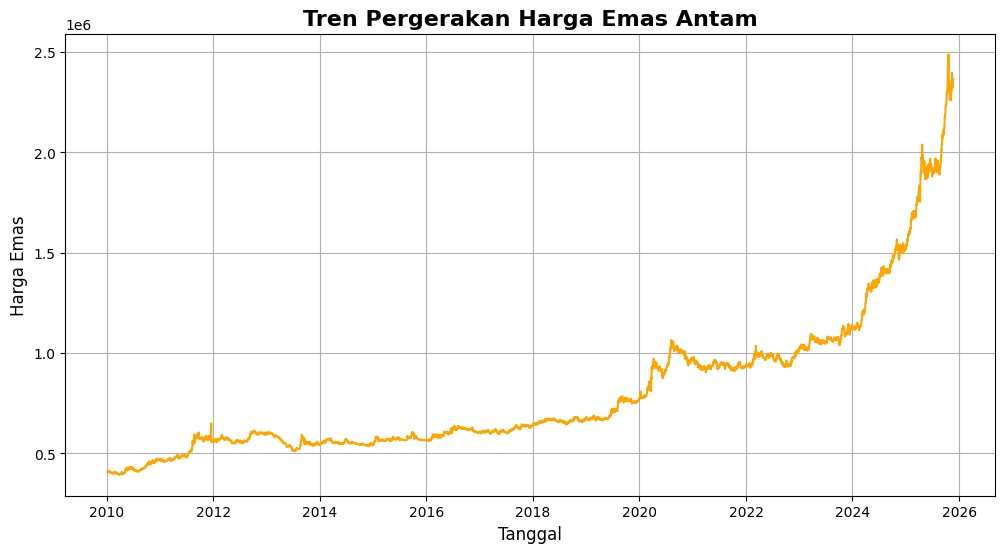

In [7]:
# 1. Mengubah kolom tanggal menjadi format datetime (karena sebelumnya masih 'object')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Menjadikan kolom 'Date' sebagai index tabel
df.set_index('Date', inplace=True)

# 3. Memvisualisasikan grafik pergerakan harga emas
plt.figure(figsize=(12, 6))

# Menggunakan 'Gold Price' sesuai dengan nama kolom di datasetmu
sns.lineplot(data=df, x=df.index, y='Gold Price', color='orange')

plt.title('Tren Pergerakan Harga Emas Antam', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Emas', fontsize=12)
plt.grid(True)
plt.show()

In [9]:
df.head()

,Time (ms),Gold Price
Date,,
2010-01-04 09:07:00,1262596020000,408000
2010-01-05 09:28:00,1262683680000,410000
2010-01-06 07:01:00,1262761260000,410000
2010-01-07 09:45:00,1262857500000,412000
2010-01-08 09:37:00,1262943420000,410000


In [11]:
print(df.columns)

Index(['Time (ms)', 'Gold Price'], dtype='object')


In [12]:
# 1. Konversi 'Time (ms)' menjadi datetime
# Kita asumsikan 'Time (ms)' sudah berupa angka milidetik yang bisa diubah ke tanggal
df['tanggal'] = pd.to_datetime(df['Time (ms)'], unit='ms')

# 2. Filter berdasarkan rentang waktu 2020-2025
df = df[(df['tanggal'] >= '2020-01-01') & (df['tanggal'] <= '2025-12-31')]

# 3. Reset Index agar urutannya rapi dari 0
df = df.reset_index(drop=True)

# 4. Update 'hari_ke' untuk model regresi
df['hari_ke'] = range(len(df))

# 5. Cek hasil akhir untuk memastikan
print(df.head())
print(df.columns)

       Time (ms)  Gold Price             tanggal  hari_ke
0  1577952627000      771000 2020-01-02 08:10:27        0
1  1578040473000      775000 2020-01-03 08:34:33        1
2  1578123795000      783000 2020-01-04 07:43:15        2
3  1578299384000      792000 2020-01-06 08:29:44        3
4  1578385487000      793000 2020-01-07 08:24:47        4
Index(['Time (ms)', 'Gold Price', 'tanggal', 'hari_ke'], dtype='object')


In [15]:
df.tail()

,Time (ms),Gold Price,tanggal,hari_ke
2100,1763454309000,2322000,2025-11-18 08:25:09,2100
2101,1763454310000,2322000,2025-11-18 08:25:10,2101
2102,1763454311000,2322000,2025-11-18 08:25:11,2102
2103,1763541343000,2343000,2025-11-19 08:35:43,2103
2104,1763628635000,2364000,2025-11-20 08:50:35,2104


In [16]:
# Menyimpan dataset yang sudah rapi ke dalam folder dataset/
df.to_csv('dataset/Antam_historical_gold_prices_clean.csv', index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!
